Study assimilation - postprocess PRO files

In [1]:
# Crop BDCLIM
from pyproj import Transformer
import xarray as xr

# Grandes Rousses Edelweiwss
lon_min, lat_min = 6.018393574207657, 44.996106812874054
lon_max, lat_max = 6.485857165463997, 45.23651632922565
# Grandes Rousses Pleiades
lon_min, lat_min = 6.066549570561894, 45.0166762840353
lon_max, lat_max = 6.318640521360017, 45.19490699670106
bdclim = xr.open_dataset("/home/imperatoren/work/edelweiss_assimilation/data/snow_depth/bdclim/snow_depth_bdclim.nc")
bdclim_grandesrousses = bdclim.where((bdclim.coords["lat"] > lat_min) * (bdclim.coords["lat"] < lat_max), drop=True).where(
    (bdclim.coords["lon"] > lon_min) * (bdclim.coords["lon"] < lon_max), drop=True
)

transformer = Transformer.from_crs(4326, 2154, always_xy=True)
x_poste, y_poste = transformer.transform(xx=bdclim_grandesrousses.lon, yy=bdclim_grandesrousses.lat)

In [ ]:
# Preprocess simulation output (assimilation of snow depth in this case)
from pandas import date_range
import numpy as np
from datetime import timedelta
from pyproj import CRS
import glob

simulation_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/edelweiss/grandesrousses250m/TEST_assim"
output_folder = "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousess250m/TEST_assim"
edel_members_files = sorted(glob.glob(f"{simulation_folder}/mb0*/pro/PRO_20220226*.nc"))
all_edel = xr.open_mfdataset(edel_members_files, concat_dim="member", combine="nested")
all_edel = all_edel.assign_coords({"member": np.arange(17)})

# date_range(all_edel.coords['time'][0])
time_sampling = date_range("2022-02-27", "2022-07-31", freq="D") + timedelta(hours=12)

all_edel_simplified = all_edel.sel(time=time_sampling)
all_edel_simplified = all_edel_simplified.drop_vars("Projection_Type")
all_edel_simplified = all_edel_simplified.rename_dims({"xx": "x", "yy": "y"}).rename({"xx": "x", "yy": "y"})
all_edel_simplified = all_edel_simplified.rio.write_crs(CRS.from_epsg(2154)).rio.write_coordinate_system()
all_edel_simplified.to_netcdf(f"{output_folder}/all_members/PRO_2022026_20220801.nc")

/tmp/ipykernel_7673/3895771294.py:19: UserWarning: rename 'xx' to 'x' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  all_edel_simplified = all_edel_simplified.rename_dims({"xx": "x", "yy": "y"}).rename({"xx": "x", "yy": "y"})
/tmp/ipykernel_7673/3895771294.py:19: UserWarning: rename 'yy' to 'y' does not create an index anymore. Try using swap_dims instead or use set_index after rename to create an indexed coordinate.
  all_edel_simplified = all_edel_simplified.rename_dims({"xx": "x", "yy": "y"}).rename({"xx": "x", "yy": "y"})


In [ ]:
3600 * 24

In [19]:
import xarray as xr

# Data preprocessed i edelweiss_vs_viirs.ipynb
forest_mask = (
    xr.open_dataarray(
        "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses/forest_mask/corine_grandesrousses_max.nc",
        engine="rasterio",
    )
    .sel(band=1)
    .drop_vars("band")
)
# viirs = preprocess_virrs(
#     xr.open_dataset(
#         "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses/reprojected_from_france_viirs/mf_fsc_l3_grandesrousses_wy_2021_2022.nc"
#     )
#     .where(forest_mask == 0)
#     .sel(time=slice("2022-01-01", "2022-06-01"))
#     .data_vars["snow_cover_fraction"]
# )
edel = (
    xr.open_dataset(
        "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousess250m/no_assim/all_members/PRO.nc"
    )
    .where(forest_mask == 0)
    .sel(time=slice("2022-02-01", "2022-06-01"))
).data_vars["DSN_T_ISBA"]
edel_assim = (
    xr.open_dataset(
        "/home/imperatoren/work/edelweiss_assimilation/simulations/postprocess/grandesrousess250m/TEST_assim/all_members/PRO_2022026_20220801.nc"
    )
    .where(forest_mask == 0)
    .sel(time=slice("2022-02-27", "2022-06-01"))
).data_vars["DSN_T_ISBA"]
pleiades = (
    xr.open_dataset(
        "/home/imperatoren/work/edelweiss_assimilation/observation_operator/data/grandesrousses/pleiades_time_series/pleaides_granderousses_all.nc"
    )
    .where(forest_mask == 0)
    .sel(time=slice("2022-02-01", "2022-06-01"))
).data_vars["snow_depth"]
bdclim = (
    bdclim_grandesrousses.assign_coords({"x": ("num_poste", x_poste), "y": ("num_poste", y_poste)})
    .data_vars["neigetotx"]
    .sel(time=slice("2022-02-01", "2022-06-01"))
    / 100
)

/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1620: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


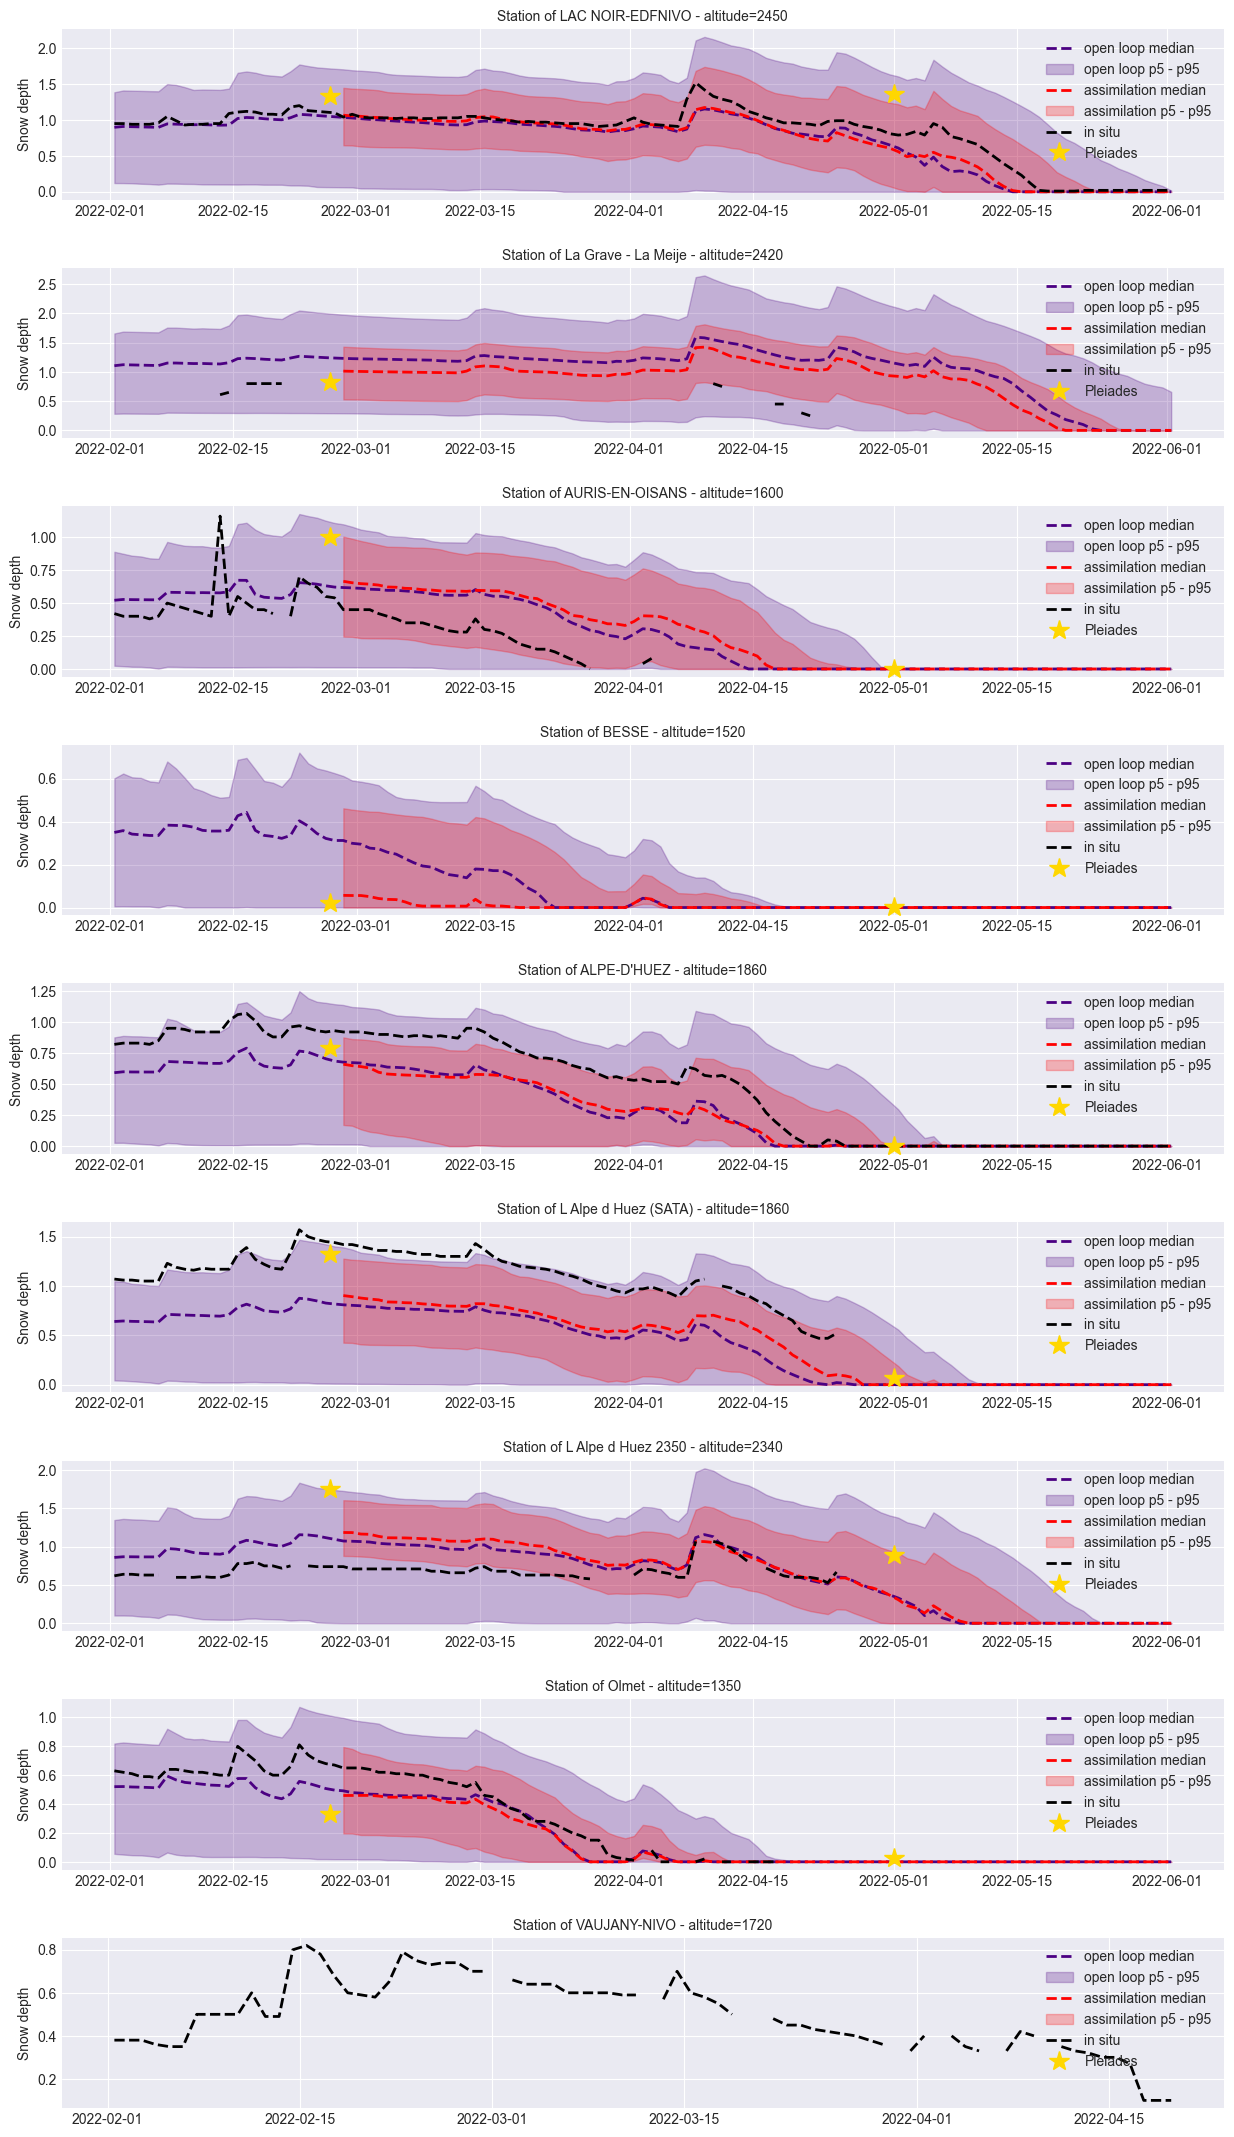

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-darkgrid")
n_tot = bdclim.sizes["num_poste"]
# n_tot = 5
fig, axs = plt.subplots(n_tot, 1, figsize=(15, 3 * n_tot))
fig.subplots_adjust(hspace=0.4)
time = edel.coords["time"]
for pp in range(n_tot):
    ax = axs[pp]
    xi, yi = x_poste[pp], y_poste[pp]
    open_loop_sd_median = edel.sel(x=xi, y=yi, method="nearest").median(dim="member")
    open_loop_sd_p5 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=0.05, dim="member")
    open_loop_sd_p95 = edel.sel(x=xi, y=yi, method="nearest").quantile(q=0.95, dim="member")

    assim_sd_median = edel_assim.sel(x=xi, y=yi, method="nearest").median(dim="member")
    assim_sd_p5 = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=0.05, dim="member")
    assim_sd_p95 = edel_assim.sel(x=xi, y=yi, method="nearest").quantile(q=0.95, dim="member")

    bdclim_poste = bdclim.where(bdclim["x"] == xi, drop=True).where(bdclim["y"] == yi, drop=True)
    pleiades_obs = pleiades.sel(x=xi, y=yi, method="nearest")

    # open_loop_until_assim = edel.sel()
    ax.plot(time, open_loop_sd_median, color="indigo", linestyle="dashed", linewidth=2, label="open loop median")
    # edel.sel(time=slice(None, '2022-02-26')).sel(x=xi, y=yi, method="nearest").plot.line(x='time', ax=ax, color="indigo",linestyle='dashed', linewidth=0.6)
    ax.fill_between(time, open_loop_sd_p5, open_loop_sd_p95, color="indigo", alpha=0.25, label="open loop p5 - p95")

    ax.plot(
        edel_assim.coords["time"], assim_sd_median, color="red", linestyle="dashed", linewidth=2, label="assimilation median"
    )
    # edel_assim.sel(x=xi, y=yi, method="nearest").plot.line(x='time', ax=ax, linestyle='dotted', color='r',linewidth=0.6)
    ax.fill_between(
        edel_assim.coords["time"], assim_sd_p5, assim_sd_p95, color="red", alpha=0.25, label="assimilation p5 - p95"
    )

    ax.plot(time, bdclim_poste.values, color="black", linestyle="dashed", linewidth=2, label="in situ")
    ax.plot(pleiades_obs.time, pleiades_obs.values, marker="*", linewidth=0, markersize=15, color="gold", label="Pleiades")
    ax.legend()
    ax.set_ylabel("Snow depth")
    ax.set_title(
        f"Station of {bdclim_poste.coords['Station_Name'].values[0]} - altitude={bdclim_poste.coords['ZS'].values[0]}",
        fontsize=10,
    )
    ax.grid(True)

In [ ]:
bdclim_grandesrousses.sel(time=slice("2021-08-02", "2022-07-31")).data_vars["neigetotx"].swap_dims(
    {"num_poste": "Station_Name"}
).to_pandas()  # .reindex({'num_poste':bdclim_grandesrousses.coords['Station_Name']})
import geopandas as gpd
from shapely import Point


def lon_lat_point(ds: xr.Dataset) -> xr.DataArray:
    return xr.DataArray(
        Point(ds.coords["lon"].values[0], ds.coords["lat"].values[0]), coords={"ZS": ds.coords["ZS"].values[0]}
    )


points = bdclim_grandesrousses.groupby("Station_Name").map(lon_lat_point)
gdf = gpd.GeoDataFrame(
    data={"Station_Name": points.coords["Station_Name"], "ZS": points.coords["ZS"]}, geometry=points.values, crs="EPSG:4326"
)
gdf.to_file("grandesrousses_pleiades_insitu_locations.shp")

/tmp/ipykernel_35894/79652864.py:14: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file('grandesrousses_pleiades_insitu_locations.shp')
/home/imperatoren/venv/edel_assim_env/lib/python3.10/site-packages/pyogrio/raw.py:733: RuntimeWarning: Normalized/laundered field name: 'Station_Name' to 'Station_Na'
  ogr_write(
